# TEM Tango Control — Client Tutorial - DB mode
Run the Tango stack before starting the client notebook.

---

## 1. Start Tango Database

```bash
TANGO_HOST=localhost:11000
uv run python -m tango.databaseds.database 2
````

Expected output:

```
Ready to accept request
```

---

## 2. Register Devices

```bash
export TANGO_HOST=localhost:11000
uv run scripts/2_register_devices.py
```

Expected output:

```
registered: test/scan/1
registered: test/eds/1
registered: test/stage/1
registered: test/microscope/1
property:   scan_device_address = test/scan/1
property:   eds_device_address = test/eds/1
property:   stage_device_address = test/stage/1
Done!
```

---

## 3. Start Servers

```bash
export TANGO_HOST=localhost:11000
uv run python -m asyncroscopy.hardware.SCAN scan_instance

export TANGO_HOST=localhost:11000
uv run python -m asyncroscopy.ThermoMicroscope microscope_instance

```

Expected:

```
Ready to accept request
```

---
If You Get “Address Already in Use” It means something is already running on that port (likely from a previous session).

Quick one-liner:
```bash
kill -9 $(lsof -t -i:11000)
```

### You can also try like this

In [ ]:
import sys
from pathlib import Path
import time
import json

# For resolving ModuleNotFoundErrors
notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent.resolve()
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

import subprocess
import numpy as np
import matplotlib.pyplot as plt
from asyncroscopy.ThermoMicroscope import ThermoMicroscope
from tango.test_context import MultiDeviceTestContext
from asyncroscopy.detectors.EDS import EDS
from asyncroscopy.hardware.SCAN import SCAN

import tango

# ── Kill anything already on port 11000 ──────────────────────────────────────
print("Clearing old processes...")
subprocess.run("kill -9 $(lsof -t -i:11000) 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'STAGE stage' 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'SCAN scan' 2>/dev/null || true", shell=True)
subprocess.run("pkill -f 'ThermoMicroscope microscope_instance' 2>/dev/null || true", shell=True)
time.sleep(2)


devices_info = [
    {
        "class": SCAN,
        "devices": [
            {
                "name": "test/detector/scan",
                "properties": {},
            }
        ],
    },

    {
        "class": EDS,
        "devices": [
            {
                "name": "test/detector/eds",
                "properties": {},
            }
        ],
    },
    
    {
        "class": ThermoMicroscope,
        "devices": [
            {
                "name": "test/detector/microscope",
                "properties": {
                    "eds_device_address": "test/detector/eds",
                    "scan_device_address": "test/detector/scan",
                },
            }
        ],
    },
]

ctx = MultiDeviceTestContext(devices_info, process=False)
ctx.start()

scan_proxy = tango.DeviceProxy("test/detector/scan")
mic_proxy = tango.DeviceProxy("test/detector/microscope")
eds_proxy = tango.DeviceProxy("test/detector/eds")

print(f"Device state: {mic_proxy.state()}")


## 1. Connect to devices

In [10]:
import os

# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:11000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"

In [12]:
# list devices on DB
import tango

db = tango.Database()

devices = db.get_device_name("*", "*")

print("Devices registered in Tango DB:\n")

for d in devices:
    print(d)

Devices registered in Tango DB:

asyncroscopy/detector/haadf
asyncroscopy/microscope/thermo
dserver/DataBaseds/2
dserver/DetectorServer/detectors
dserver/EDS/eds_instance
dserver/HAADF/haadf_instance
dserver/MicroscopeServer/microscope
dserver/SCAN/scan_instance
dserver/STAGE/eds_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/eds/1
test/haadf/1
test/microscope/1
test/scan/1
test/stage/1


### Interpreting the Tango Device List

When listing devices from the Tango database, you will typically see three categories:

- **User devices**  
  Actual devices your application interacts with via `DeviceProxy`.  
  Example: `test/haadf/1`, `test/microscope/1`.

- **`dserver/...` devices**  
  Administrative devices automatically created for each running device server.  
  Used for monitoring and controlling server processes.

- **`sys/...` devices**  
  Core Tango system services (e.g., database, access control).  
  Part of the Tango infrastructure.

👉 In practice, users typically interact only with the **user devices**.

In [17]:
import json
import numpy as np
import matplotlib.pyplot as plt
import tango


# --nodb mode — use full tango:// URL with port and #dbase=no suffix
microscope_proxy = tango.DeviceProxy("test/microscope/1")
microscope_proxy.set_timeout_millis(120_000)

scan_proxy = tango.DeviceProxy("test/scan/1")

In [14]:
print('Microscope state:', microscope_proxy.state())


Microscope state: ON


## 2. Inspect device attributes and commands

In [15]:
print('\n--- Microscope commands ---')
for cmd in microscope_proxy.get_command_list():
    print(f'  {cmd}')


--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  blank_beam
  get_image_data_cached
  get_images
  get_scanned_image
  get_spectrum
  get_stage
  move_stage
  place_beam
  set_fov
  unblank_beam


## 3. Configure HAADF detector settings

In [18]:
scan_proxy.dwell_time 

1e-06

In [21]:
scan_proxy.dwell_time   = 10e-6   # 1 µs
scan_proxy.imsize  = 1024


print('dwell_time  :', scan_proxy.dwell_time)
print('image_width :', scan_proxy.imsize)


dwell_time  : 1e-05
image_width : 1024


## 4. Acquire a HAADF image

In [25]:
# get_image returns DevEncoded = (json_metadata_str, raw_bytes)
json_meta, raw_bytes = microscope_proxy.get_scanned_image()

metadata  = dict(json.loads(json_meta))
image = np.frombuffer(raw_bytes, dtype=metadata['dtype']).reshape(metadata['shape'])

print('Metadata:', metadata)
print('Image shape:', image.shape)
print('Image dtype:', image.dtype)

Metadata: {'detector': 'haadf', 'shape': [1024, 1024], 'dtype': 'uint16', 'dwell_time': 1e-05, 'timestamp': 1774449916.897834}
Image shape: (1024, 1024)
Image dtype: uint16


## 5. Display the image

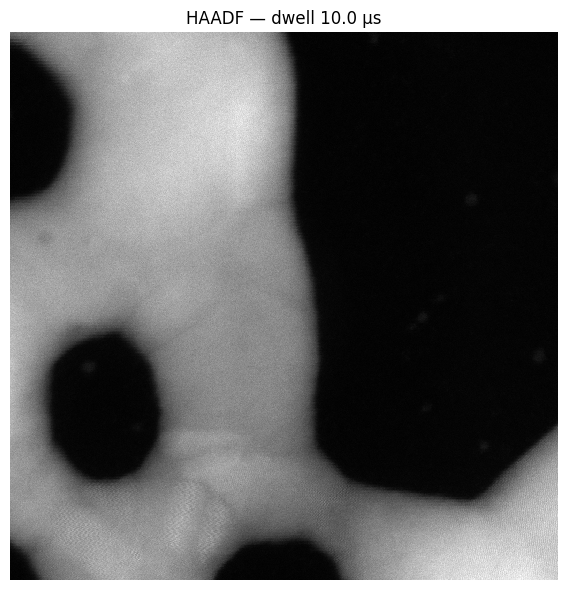

In [26]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap='gray', interpolation='none')
ax.set_title(f"HAADF — dwell {metadata['dwell_time']*1e6:.1f} µs")
ax.axis('off')
plt.tight_layout()
plt.show()

### Sidpy dataset

In [20]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np

import sidpy
print('sidpy version: ', sidpy.__version__)

sidpy version:  0.12.8


In [38]:
dataset = sidpy.Dataset.from_array(image , name='random')

# set dimesnions
dataset.set_dimension(0, sidpy.Dimension(np.arange(image.shape[0])*.02, 'x'))
dataset.set_dimension(1, sidpy.Dimension(np.arange(image.shape[0])*.02, 'y'))


# set the dataset level plotting metadata
dataset.data_type = 'image'
dataset.units = 'counts'
dataset.quantity = 'intensity'
dataset.title = 'random'

# handle one dimension of the data
dataset.set_dimension(0, sidpy.Dimension(np.arange(dataset.shape[0])*.02, 'x'))
dataset.x.dimension_type = 'spatial'
dataset.x.units = 'nm'
dataset.x.quantity = 'distance'

# handle another dimension of the data

dataset.set_dimension(1, sidpy.Dimension(np.arange(dataset.shape[1])*.02, 'y'))
dataset.y.dimension_type = 'spatial'
dataset.y.units = 'nm'
dataset.y.quantity = 'distance'


In [39]:
dataset.metadata = metadata

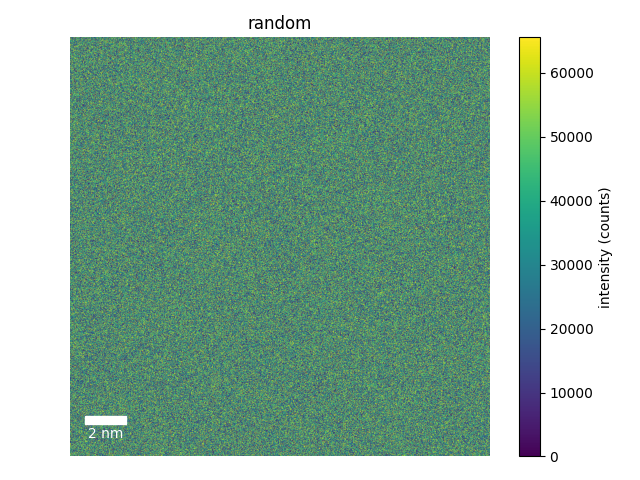

In [40]:
view = dataset.plot(scale_bar=True)

## 6. Advanced acquisition (multi-detector)


Start the AdvancedAcquisition detector:

```bash
uv run python -m tango.test_context asyncroscopy.acquistion.advanced_acquisition.AdvancedAcquisition --host 127.0.0.1 --port 8890
```

Start the Microscope (in a separate terminal):

```bash
uv run python -m tango.test_context asyncroscopy.Microscope.Microscope --host 127.0.0.1 --port 8889 \
  --prop "{'haadf_device_address': 'tango://127.0.0.1:8888/test/nodb/haadf#dbase=no',
  'advanced_acquisition_device_address' : 'tango://127.0.0.1:8890/test/nodb/advancedacquisition#dbase=no'}"
```

In [30]:
adv_acq_proxy = tango.DeviceProxy("tango://127.0.0.1:8890/test/nodb/advancedacquisition#dbase=no")


In [31]:
adv_acq_proxy.state()

<DevState.ON: 0>

In [32]:
for attr in adv_acq_proxy.get_attribute_list():
    print(f'  {attr}')



  dwell_time
  base_resolution
  scan_region
  auto_beam_blank
  State
  Status


In [33]:
adv_acq_proxy.dwell_time

1e-06

In [ ]:
adv_acq_proxy.scan_region

In [34]:
# One simultaneous acquisition
response = microscope_proxy.get_images(["HAADF", "HAADF"])
info = json.loads(response)


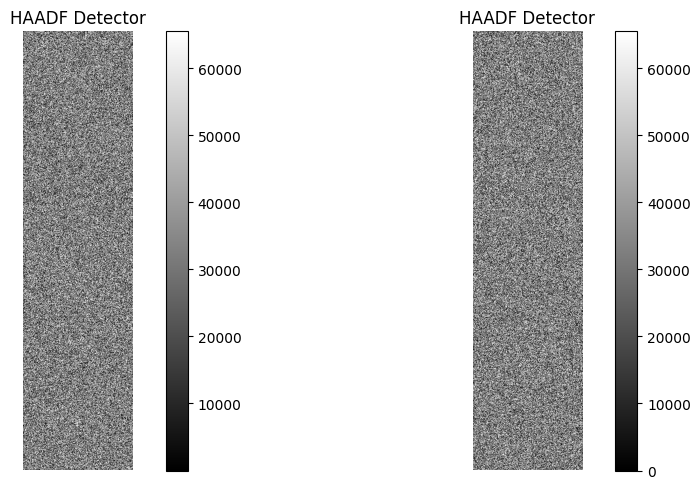

In [ ]:
import matplotlib.pyplot as plt

# Quick retrieval
images = []
for img_meta in info["images"]:
    meta_json, img_bytes = microscope_proxy.get_image_data_cached(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    images.append((img_meta["detector"], img))

# Plot all images
fig, axes = plt.subplots(1, len(images), figsize=(6*len(images), 5))

# Handle single image case
if len(images) == 1:
    axes = [axes]

for ax, (detector_name, img) in zip(axes, images):
    im = ax.imshow(img, cmap='gray')
    ax.set_title(f"{detector_name.upper()} Detector")
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()

Sidpy 

In [39]:
import json
import numpy as np
import matplotlib.pyplot as plt
import sidpy

# Step 1: Acquire images simultaneously
response = microscope_proxy.get_images(["HAADF", "HAADF"])
info = json.loads(response)

# Step 2: Create sidpy datasets for each image
datasets = []

for img_meta in info["images"]:
    # Get the cached image
    meta_json, img_bytes = microscope_proxy.get_image_data(img_meta["index"])
    img = np.frombuffer(img_bytes, dtype=img_meta["dtype"]).reshape(img_meta["shape"])
    
    # Create sidpy dataset
    dataset = sidpy.Dataset.from_array(img, name=img_meta["detector"])
    
    # Set dimensions (assuming 0.02 nm/pixel - adjust as needed)
    dataset.set_dimension(0, sidpy.Dimension(np.arange(img.shape[0]) * 0.02, 'x'))
    dataset.set_dimension(1, sidpy.Dimension(np.arange(img.shape[1]) * 0.02, 'y'))
    
    # Set dataset metadata
    dataset.data_type = 'image'
    dataset.units = 'counts'
    dataset.quantity = 'intensity'
    dataset.title = img_meta["detector"].upper()
    
    # X dimension metadata
    dataset.x.dimension_type = 'spatial'
    dataset.x.units = 'nm'
    dataset.x.quantity = 'distance'
    
    # Y dimension metadata
    dataset.y.dimension_type = 'spatial'
    dataset.y.units = 'nm'
    dataset.y.quantity = 'distance'
    
    # Store acquisition metadata
    dataset.metadata = img_meta
    
    datasets.append(dataset)



In [40]:
datasets

[sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(819, 204), dtype=uint16, chunksize=(819, 204), chunktype=numpy.ndarray>
  data contains: intensity (counts)
  and Dimensions: 
 x:  distance (nm) of size (819,)
 y:  distance (nm) of size (204,)
  with metadata: ['index', 'detector', 'shape', 'dtype', 'timestamp'],
 sidpy.Dataset of type IMAGE with:
  dask.array<array, shape=(819, 204), dtype=uint16, chunksize=(819, 204), chunktype=numpy.ndarray>
  data contains: intensity (counts)
  and Dimensions: 
 x:  distance (nm) of size (819,)
 y:  distance (nm) of size (204,)
  with metadata: ['index', 'detector', 'shape', 'dtype', 'timestamp']]